In [1]:
from IPython.display import HTML
HTML(open ("../style.css").read())

In [2]:
%load_ext nb_mypy

Version 1.0.6


# Handwritten Digit Recognition

In this notebook we show how a *fully connected feed-forward* neural networks can be used to recognize handwritten digits.

The data that we are using is stored in a <a href="https://docs.python.org/3/library/gzip.html">gzipped</a>, 
<a href="https://docs.python.org/3/library/pickle.html">pickled</a> file.  Therefore, we need to import the corresponding libraries to access the data. 
  * `gzip` is a library that can be used to read and automatically uncompress a
    compressed file.  
    
    Its API offers the method `gzip.open(fn, md)`.  
    This method takes two inputs.
    + `fn` is a filename.
    + `md` is a mode to open the associated file. 
    
       The mode determines whether the file is opened for reading, writing, or          appending and whether the file is a binary file.
       
    The method returns a file handle.
  * `pickle` is a library that can be used to package and unpackage 
    data structures into a binary format.  
    
    Its API offers the method `pickle.load(h, e)`.  
    This method takes two inputs.
    + `h` is a file handle.
    + `e` is a file encoding, e.g. something like `latin1`.
    
    The method returns the data structure that has been stored in the file
    specified by the file handle `h`.

In [3]:
import gzip
import pickle

As our data is stored as a tuple of `numpy` arrays, we have to import numpy.

In [4]:
import numpy as np

In order to be able to show the images of the handwritten digits, we use `matplotlib`.

In [5]:
import matplotlib.pyplot as plt

We need to import the module `random` as we are using <em style="color:blue">stochastic gradient descent</em> to compute the weights of our neural network.

In [6]:
import random

The function $\texttt{vectorized_result}(d)$ converts a digit $d \in \{0,\cdots,9\}$ into a `numpy` array $\mathbf{y}$ of shape $(10, 1)$ such that we have
$$
\mathbf{y}[i] = 
\left\{
  \begin{array}{ll}
     1 & \mbox{if $i = d$;} \\
     0 & \mbox{otherwise}
  \end{array}  
\right.
$$
for all $i \in \{0,\cdots,9\}$.
This function is used to convert a digit $d$ into the expected output of a neural network that has an output unit for every digit. 

This type of encoding is also known as a *hot one encoding*.

In [7]:
def vectorized_result(d: int) -> np.ndarray:
    return np.eye(10, dtype=np.float32)[d].reshape(10, 1)

In [8]:
vectorized_result(2)

array([[0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32)

The file `mnist.pkl.gz` contains a triple of the form
```
train, validate, test
```
Here `train` is a pair of the form `(X, y)` where
- `X` is a numpy array of shape `(50000, 784)`,
- `y` is a numpy array of shape `(50000, )`.

For every $i \in \{0,\cdots, 49,999\}$ we have that $\textbf{X}[i]$ is an image of a handwritten digit and $\textbf{y}[i]$ is a digit, i.e. an element of the set 
$\{0,\cdots,9\}$.

The structure of `validate` and `test` is similar, but these contain only $10,000$ images each.

The function $\texttt{load_data}()$ returns a pair of the form
$$ (\texttt{training_data}, \texttt{test_data}) $$
where 
- $\texttt{training_data}$ is a list containing 50,000 pairs $(\textbf{x}, \textbf{y})$       s.t. 
  - $\textbf{x}$ is a 784-dimensional `numpy.ndarray` containing the input image, and   
  - $\textbf{y}$ is a 10-dimensional `numpy.ndarray` corresponding to the correct digit for 
    $\textbf{x}$.   
- To keep things simple, we do not use the validation data.
- $\texttt{test_data}$ is a list containing 10,000 pairs $(\textbf{x}, y)$.  In each case, 
  $\textbf{x}$ is a 784-dimensional `numpy.ndarray` containing the input image, 
  and $y \in \{0,\cdots,9\}$ is the corresponding digit value.

Note that the formats for training data and test data are different.  For the training data $\textbf{y}$ is a vector, but for the test data $y$ is a digit.

**Note** that we have to use 
```
np.reshape(x, (784, 1))
```
in order to be able to use the operator `@` for matrix multiplication later, as `@` can't be used to multiply a matrix with a vector, it can only multiply vectors.

In [9]:
def load_data() -> tuple[list[tuple[np.ndarray, np.ndarray, int]], 
                         list[tuple[np.ndarray, int]]
                        ]:
    with gzip.open('../mnist.pkl.gz', 'rb') as f:
        train, _, test = pickle.load(f, encoding="latin1")
    print(f'shape of training data: {(train[0].shape, train[1].shape)}')
    training_inputs    = [np.reshape(x, (784, 1)) for x in train[0]]
    training_results   = [vectorized_result(y) for y in train[1]]
    training_data      = list(zip(training_inputs, training_results, train[1]))
    test_inputs        = [np.reshape(x, (784, 1)) for x in test[0]]
    test_data          = list(zip(test_inputs, test[1]))
    return training_data, test_data

In [10]:
list(zip([1, 2, 3], ['a', 'b', 'c'], [4, 5, 6]))

[(1, 'a', 4), (2, 'b', 5), (3, 'c', 6)]

We store the data in two variables: `training_data` and `test_data`. 
- `training_data` is a list of triples of the form $(\textbf{x}, \textbf{y}, d)$ where 
   $\textbf{x}$ is a `numpy` array of shape $(784, 1)$ representing the image of a digit, 
   while $\textbf{y}$ is a `numpy` array of shape $(10, 1)$ that is a 
   <a href="https://en.wikipedia.org/wiki/One-hot">one-hot encoding</a> 
   of the digit shown in $\textbf{x}$. Finally, $d$ is the digit.
- `test_data` is a list of pairs of the form $(\textbf{x}, d)$ where 
   $\textbf{x}$ is a `numpy` array of shape $(784, 1)$ representing the image of a digit, 
   while $d$ is the digit that is shown, i.e. it is an element of the set $\{0,\cdots,9\}$.

In [11]:
training_data, test_data = load_data()

shape of training data: ((50000, 784), (50000,))


Let us take a look the first feature vector.

The function $\texttt{show_digit}(\texttt{row}, \texttt{columns}, \texttt{offset})$ 
shows $\texttt{row} \cdot \texttt{columns}$ images of the training data.  The first image shown is the image at index $\texttt{offset}$.

In [12]:
def show_digits(data: list[tuple[np.ndarray, np.ndarray, int]], rows: int, columns: int, offset: int = 0) -> None:
    _, axarr = plt.subplots(rows, columns)
    for r in range(rows):
        for c in range(columns):
            i     = r * columns + c + offset
            image = 1 - data[i][0]
            image = np.reshape(image, (28, 28))
            axarr[r, c].imshow(image, cmap="gray")
            axarr[r, c].axis('off')
    plt.savefig("digits.pdf")    
    plt.show()

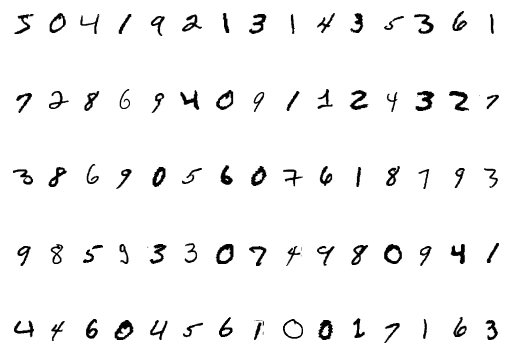

In [13]:
show_digits(training_data, 5, 15, 0)

Our goal is to find the <em style="color:blue;">weight matrices</em> and <em style="color:blue;">biases</em> for a neural net that is 
able to recognize the digits shown in these images.  We initialize these weight matrices randomly. The function $\texttt{rndMatrix}(\texttt{rows}, \texttt{cols})$ returns a matrix of shape $(\texttt{rows}, \texttt{cols})$ that is filled with random numbers that have a Gaussian distribution with mean $0$ and variance $\displaystyle\frac{1}{\texttt{cols}}$.

In [14]:
def rndMatrix(rows: int, cols: int) -> np.ndarray:
    return np.random.randn(rows, cols) / np.sqrt(cols)

In [15]:
rndMatrix(2, 2)

array([[0.16875863, 0.81829801],
       [1.12308604, 0.49755752]])

The function $\texttt{sigmoid}(x)$ computes the sigmoid of $x$, which is defined as
$$ \texttt{sigmoid}(x) = S(x) := \frac{1}{1 + \texttt{exp}(-x)}. $$ 
Since we are using NumPy to compute the exponential function, this function also works when $x$ is a vector.

In [16]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

In [17]:
sigmoid(np.array([-1, 0, 1]))

array([0.26894142, 0.5       , 0.73105858])

The function $\texttt{sigmoid_prime}(x)$ computes the derivative of the sigmoid function for $x$.  The implementation is based on the equation:
$$ S'(x) = S(x) \cdot \bigl(1 - S(x)\bigr) $$
Here $x$ can either be a number or a `numpy`-vector.

In [18]:
def sigmoid_prime(x: np.ndarray) -> np.ndarray:
    s = sigmoid(x)
    return s * (1 - s)

In [20]:
sigmoid_prime(np.array([-5, 0, 5]))

array([0.00664806, 0.25      , 0.00664806])

The class `Network` is used to represent a *feed-forward neural network* with one hidden layer.
The constructor is called with the argument `hiddenSize`.  This parameter specifies the number of neurons in the hidden layer.  The network has $28 \cdot 28 = 784$ input nodes.  Each of the input nodes corresponds to the gray scale value of a single pixel in a $28 \cdot 28$ gray scale image of the digit that is to be recognized.  The number of output neurons is 10.  For $i \in \{0,\cdots,9\}$, the $i^{\textrm{th}}$ output neuron tries to recognize the digit $i$.

In [21]:
class Network(object):
    mInputSize:  int
    mHiddenSize: int
    mOutputSize: int
    mBiasesH:    np.ndarray
    mBiasesO:    np.ndarray
    mWeightsH:   np.ndarray
    mWeightsO:   np.ndarray

    def __init__(self, hiddenSize: int) -> None:
        self.mInputSize  = 28 * 28
        self.mHiddenSize = hiddenSize
        self.mOutputSize = 10
        self.mBiasesH    = np.zeros((self.mHiddenSize, 1))   # biases hidden layer
        self.mBiasesO    = np.zeros((self.mOutputSize, 1))   # biases output layer
        self.mWeightsH   = rndMatrix(self.mHiddenSize, self.mInputSize)  # weights hidden layer
        self.mWeightsO   = rndMatrix(self.mOutputSize, self.mHiddenSize) # weights output layer

    # The following forward definitions are needed for the type checker    
    def feedforward(self, x: np.ndarray) -> np.ndarray:
        raise NotImplementedError()
        
    def sgd(self, training_data: list[tuple[np.ndarray, np.ndarray, int]], epochs: int, mbs: int, 𝛼: float) -> None:
        raise NotImplementedError()
        
    def update_mini_batch(self, mini_batch: list[tuple[np.ndarray, np.ndarray, int]], 𝛼: float) -> None:
        raise NotImplementedError()
        
    def backprop(self, X: np.ndarray, Y: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        raise NotImplementedError()
        
    def evaluate(self, data: list[tuple[np.ndarray, np.ndarray, int]]) -> int:
        raise NotImplementedError()
        
    def accuracy(self, data: list[tuple[np.ndarray, int]]) -> float:
        raise NotImplementedError()

Given a neural network $n$ and an input vector $x$ for this neural network, the function $n.\texttt{feedforward}(x)$ computes the output of the neural network.
The code is a straightforward implementation of the feedforward equations.  
These equations are repeated here for convenience:
- $\mathbf{a}^{(1)}(\mathbf{x}) = \mathbf{x}$ 
- $\mathbf{a}^{(l)}(\mathbf{x}) = S\Bigl( W^{(l)} \cdot \mathbf{a}^{(l-1)}(\mathbf{x}) + \mathbf{b}^{(l)}\Bigr)$
  for all $l \in \{2, 3\}$.

The input $\mathbf{x}$ is the activation of the input layer and therefore is equal to $\mathbf{a}^{(1)}(\mathbf{x})$.
`AH` is the activation of the hidden layer and hence equal to $\mathbf{a}^{(2)}(\mathbf{x})$, while 
`AO` is the activation of the output layer and therefore equal to $\mathbf{a}^{(3)}(\mathbf{x})$.

In [22]:
def feedforward(self: 'Network', x: np.ndarray) -> np.ndarray:
    AH = sigmoid(self.mWeightsH @ x  + self.mBiasesH) # hidden layer
    AO = sigmoid(self.mWeightsO @ AH + self.mBiasesO) # output layer
    return AO

The next command turns the *function* `feedword` into a *method* of the class `Network`.
Afterwards, the *function* `feedforward` is deleted, i.e. it is removed from the global namespace.

In [23]:
Network.feedforward = feedforward  # type: ignore[assignment]
del feedforward

Given a neural network $n$, the method `sgd(training_data, epochs, mbs, 𝛼)` uses *stochastic gradient descent* to train the network.  The parameters are as follows:
* `training_data` is a list of tuples of the form $(x, y)$ where $x$ is an 
  input of the neural net and $y$ is a vector of length 10 representing the desired output. 
* `epochs` is the number of epochs to train,
* `mbs` is short for *minibatch size*,
* `𝛼` is the *learning rate*.

In [24]:
def sgd(self:          'Network', 
        training_data: list[tuple[np.ndarray, np.ndarray, int]], 
        epochs:        int, 
        mbs:           int, 
        𝛼:             float) -> None:
    n = len(training_data)
    for j in range(epochs):
        random.shuffle(training_data)
        mini_batches = [training_data[k:k+mbs] for k in range(0, n, mbs)]
        for mini_batch in mini_batches:
            self.update_mini_batch(mini_batch, 𝛼)    
        print(f'Epoch {j:2d}: {100 * self.evaluate(training_data) / n:.2f} %')
        
Network.sgd = sgd  # type: ignore[assignment]
del sgd

The method `update_mini_batch` performs one step of gradient descent for the data from one 
mini-batch.  It receives two arguments.
- `mini_batch` is the list of training data that constitute one mini-batch.
- `𝛼` is the *learning rate*.

To significantly speed up training, we vectorize the processing of the mini-batch:
- First, we horizontally stack all input vectors $\mathbf{x}$ and expected output vectors $\mathbf{y}$ from the mini-batch into matrices $X$ and $Y$.
- Next, we call `backprop(X, Y)` to compute the gradients of the cost function with respect to the biases and weights for the entire mini-batch simultaneously.
- Finally, the bias vectors and the weight matrices are updated according to the learning 
  rate and the computed gradients.

In [25]:
def update_mini_batch(
        self:       'Network', 
        mini_batch: list[tuple[np.ndarray, np.ndarray, int]], 
        𝛼:          float
) -> None:
    X = np.hstack([x for x, _, _ in mini_batch])
    Y = np.hstack([y for _, y, _ in mini_batch])
    
    nabla_BH, nabla_BO, nabla_WH, nabla_WO = self.backprop(X, Y)
    
    𝛼 /= len(mini_batch)            # rescale learning rate
    self.mBiasesH  -= 𝛼 * nabla_BH
    self.mBiasesO  -= 𝛼 * nabla_BO
    self.mWeightsH -= 𝛼 * nabla_WH
    self.mWeightsO -= 𝛼 * nabla_WO

Network.update_mini_batch = update_mini_batch  # type: ignore[assignment]
del update_mini_batch

Given a neural network $n$, the method $n.\texttt{backprop}(X, Y)$ takes a matrix of training examples $X$ and their corresponding expected outputs $Y$, and calculates the gradient of the cost function with respect to the entire mini-batch.  This is done by implementing the 
<em style="color:blue">vectorized backpropagation equations</em> shown below:

$$
\begin{array}[h]{llr}
  E^{(L)} = (A^{(L)} - Y) \odot S'\bigl(Z^{(L)}\bigr)
     & & \mbox{(BP1m)}  \\
  E^{(l)} = \Bigl(\bigl(W^{(l+1)}\bigr)^\top \cdot E^{(l+1)}\Bigr) \odot
  S'\bigl(Z^{(l)}\bigr) & \mbox{for all $l \in \{2, \cdots, L-1\}$} &
  \mbox{(BP2m)}  \\
  \nabla_{\mathbf{b}^{(l)}} C = \sum_{i=1}^{m} E^{(l)}_{(i)}
  & \mbox{for all $l \in \{2, \cdots,L\}$}
  & \mbox{(BP3m)}
  \\
  \nabla_{W^{(l)}} C = E^{(l)} \cdot \bigl(A^{(l-1)}\bigr)^\top
  & \mbox{for all $l \in \{2, \cdots,L\}$}
  & \mbox{(BP4m)}
\end{array}
$$
Here, $E^{(l)}_{(i)}$ denotes the $i^{\textrm{th}}$ column of the error matrix $E^{(l)}$, and the sum computes the row-wise sum.

In [26]:
def backprop(
        self: 'Network', 
        X:    np.ndarray, 
        Y:    np.ndarray
    ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    # feedforward pass
    ZH = self.mWeightsH @ X  + self.mBiasesH
    AH = sigmoid(ZH)
    ZO = self.mWeightsO @ AH + self.mBiasesO
    AO = sigmoid(ZO)
    # backwards pass, output layer
    epsilonO = (AO - Y) * sigmoid_prime(ZO)
    nabla_BO = np.sum(epsilonO, axis=1, keepdims=True)
    nabla_WO = epsilonO @ AH.T
    # backwards pass, hidden layer
    epsilonH = (self.mWeightsO.T @ epsilonO) * sigmoid_prime(ZH)
    nabla_BH = np.sum(epsilonH, axis=1, keepdims=True)
    nabla_WH = epsilonH @ X.T
    return nabla_BH, nabla_BO, nabla_WH, nabla_WO

Network.backprop = backprop  # type: ignore[assignment]
del backprop

Given a neural network `n`, the method `n.evaluate(test_data)` uses the test data to compute  the number of examples that are predicted correctly by the neural network `n`.

In [27]:
def evaluate(
    self: 'Network', 
    data: list[tuple[np.ndarray, np.ndarray, int]]
) -> int:
    X = np.hstack([x for x, _, _ in data])
    Y_actual = np.array([y for _, _, y in data])
    Y_pred = np.argmax(self.feedforward(X), axis=0)
    return int(np.sum(Y_pred == Y_actual))

Network.evaluate = evaluate  # type: ignore[assignment]
del evaluate

The method `nn.accuracy(data)` returns the accuracy of the neural network `nn` for the given test `data`.

In [28]:
def accuracy(
    self: 'Network', 
    data: list[tuple[np.ndarray, int]]
) -> float:
    X = np.hstack([x for x, _ in data])
    Y_actual = np.array([y for _, y in data])
    Y_pred = np.argmax(self.feedforward(X), axis=0)
    return 100 * float(np.sum(Y_pred == Y_actual)) / len(data)

Network.accuracy = accuracy  # type: ignore[assignment]
del accuracy

In [29]:
%%time
np.random.seed(1)
net = Network(50)
net.sgd(training_data, 45, 10, 0.25)

Epoch  0: 90.58 %
Epoch  1: 92.53 %
Epoch  2: 93.44 %
Epoch  3: 94.11 %
Epoch  4: 94.72 %
Epoch  5: 95.09 %
Epoch  6: 95.48 %
Epoch  7: 95.75 %
Epoch  8: 95.97 %
Epoch  9: 96.15 %
Epoch 10: 96.42 %
Epoch 11: 96.56 %
Epoch 12: 96.76 %
Epoch 13: 96.81 %
Epoch 14: 96.95 %
Epoch 15: 97.12 %
Epoch 16: 97.24 %
Epoch 17: 97.33 %
Epoch 18: 97.43 %
Epoch 19: 97.48 %
Epoch 20: 97.61 %
Epoch 21: 97.64 %
Epoch 22: 97.70 %
Epoch 23: 97.83 %
Epoch 24: 97.84 %
Epoch 25: 97.93 %
Epoch 26: 97.97 %
Epoch 27: 97.99 %
Epoch 28: 98.07 %
Epoch 29: 98.11 %
Epoch 30: 98.19 %
Epoch 31: 98.22 %
Epoch 32: 98.26 %
Epoch 33: 98.29 %
Epoch 34: 98.31 %
Epoch 35: 98.32 %
Epoch 36: 98.38 %
Epoch 37: 98.37 %
Epoch 38: 98.47 %
Epoch 39: 98.46 %
Epoch 40: 98.46 %
Epoch 41: 98.51 %
Epoch 42: 98.55 %
Epoch 43: 98.53 %
Epoch 44: 98.60 %
CPU times: user 1min 10s, sys: 2min 1s, total: 3min 11s
Wall time: 41.4 s


In [30]:
print(f'Accuracy on test data: {net.accuracy(test_data):.2f} %') # type: ignore

Accuracy on test data: 96.87 %


What is the number of parameters of our network? 
- The hidden layer has 50 neurons that each have a bias parameter and 784 
  weight parameters for the connections to the input nodes.
- The output layer has 10 neurons that each have a bias parameter and 40 
  weight parameters for the connections to the hidden layer.
  
Therefore the network has 
$$ 50 \cdot (1 + 784) + 10 \cdot (1 + 50) = 39,760 $$
parameters.  As we have $50,000$ training data and every training datum gives rise to 10 equations, we shouldn't be too worried about over-fitting.

In [ ]:
50 * (1 + 784) + 10 * (1 + 50)